# Resort Churn Prediction — Classical ML + Optuna

**Goal.** Predict the binary `Churned` flag for resort guests in `resort_test.csv` and write a `submission.csv` file containing `GuestID,Churned` rows.

**Workflow.**
1. Load the raw train / test CSVs straight from GitHub.
2. Clean the data: fix the corrupted-decimal amenity values, parse `BookingDate`, split the composite `Room` code, and add missingness indicators.
3. Export the cleaned + engineered training frame to `cleaned_data.csv`.
4. Build a `ColumnTransformer` so the *same* preprocessing is applied to train and test.
5. Run a quick 5-fold cross-validated bake-off between Logistic Regression, Random Forest, Gradient Boosting, HistGradientBoosting, XGBoost, LightGBM, and CatBoost to pick the strongest model family.
6. Hyper-parameter tune the winner (CatBoost) with **Optuna** (TPE sampler, ROC-AUC objective, 5-fold stratified CV).
7. Re-fit the tuned model on the full training set and produce `submission.csv`.

Each section is self-contained and re-runnable from the top.

## 1. Imports

Standard PyData stack plus the three boosted-tree libraries (`xgboost`, `lightgbm`, `catboost`) and `optuna` for hyper-parameter search.

In [17]:
# If anything is missing, uncomment:
# %pip install pandas numpy scikit-learn xgboost lightgbm catboost optuna matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the data

We load directly from the GitHub `raw.githubusercontent.com` host — the `github.com/.../blob/...` URL would return rendered HTML rather than the CSV bytes.

In [18]:
TRAIN_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv"
TEST_URL  = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_test.csv"

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

print(f"Train shape: {train_raw.shape}")
print(f"Test  shape: {test_raw.shape}")
train_raw.head()

Train shape: (6954, 21)
Test  shape: (1739, 20)


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


In [19]:
#drop the VIP and ReferralSource columns from the test and training datasets
train_raw.drop(columns=['VIP'], inplace=True)
test_raw.drop(columns=['VIP'], inplace=True)

### 2a. Quick look at the schema

Note the mix of types and the very high missing-rate / outlier behaviour in some of the spend columns (`Dining`, `Spa`, `Entertainment`, …). We will handle these in the cleaning step.

In [20]:
summary = pd.DataFrame({
    "dtype": train_raw.dtypes,
    "missing": train_raw.isna().sum(),
    "missing_pct": (train_raw.isna().mean() * 100).round(1),
    "nunique": train_raw.nunique(),
})
summary

,dtype,missing,missing_pct,nunique
GuestID,int64,0,0.0,6954
BookingDate,object,0,0.0,658
PromoCode,object,3245,46.7,2
Region,object,169,2.4,3
AllInclusive,float64,168,2.4,2
Room,object,386,5.6,5297
PackageType,object,153,2.2,3
Age,float64,476,6.8,80
RoomService,float64,464,6.7,1197
Dining,float64,488,7.0,1345


In [21]:
# Target balance — modestly imbalanced, so we will use ROC-AUC as the primary CV metric.
train_raw["Churned"].value_counts(normalize=True).rename("share").to_frame()

,share
Churned,
1,0.503595
0,0.496405


## 3. Cleaning + feature engineering

Everything that needs raw-row context (string parsing, date math, `Room` decomposition, the row-wise amenity fix) lives in a single pure function `engineer(df)` so that it can be applied identically to train and test.

### Amenity outlier rule

The amenity-spend columns — `RoomService`, `Dining`, `Retail`, `Spa`, `Entertainment` — are *supposed* to be integers. The dataset contains a handful of absurd six-figure values like `336519.8436426201`, and every one of them has a non-zero fractional part. We treat that as a data-entry corruption rather than a real spend value.

**Per-row rule** (applies independently to each guest):

1. A cell is **bad** if it is missing *or* has a non-zero fractional part.
2. If at least one of the 5 amenity cells is **good** (clean integer), replace every bad cell in that row with the *rounded mean* of the good cells — assume the guest used the amenity but the value got mangled in recording.
3. If **all 5** cells are bad, we have no information to lean on, so fill them all with **0** (assume no amenity usage).

Other engineering:

* **`BookingDate`** → year, month, day-of-week, is-weekend, days-since-earliest-booking.
* **`Room`** (e.g. `"G/630/S"`) → split into `RoomBuilding`, `RoomNumber`, `RoomSection`.
* **`Age`** — the dataset uses `0.0` as a sentinel for unknown, so replace it with NaN and let the imputer handle it. Also derive an `AgeKnown` flag.
* **Spend aggregates** — `TotalSpend`, `TotalSpend_log`, `SpendCategories`, and per-column `log1p` features for the linear model.
* **Missing-indicator columns** for the fields where NaN itself is a signal (`PromoCode`, `AllInclusive`, `Region`).
* **Drop** `BookingDate` and the original `Room` string (replaced by their derived columns).

In [22]:
AMENITIES = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]
EARLIEST_BOOKING = pd.to_datetime(train_raw["BookingDate"], errors="coerce").min()
print(f"Earliest booking date in train: {EARLIEST_BOOKING.date()}")

Earliest booking date in train: 2023-01-01


In [23]:
def fix_amenity_decimals(df: pd.DataFrame, cols=AMENITIES) -> pd.DataFrame:
    """Row-wise repair of corrupted decimal values in the amenity-spend columns.

    For each row:
      * A cell is "bad" if it is NaN OR has a non-zero fractional part.
      * If 1-4 cells are bad, fill each bad cell with round(mean(good cells)).
      * If all 5 cells are bad, fill with 0.

    Returns a new dataframe with the amenity columns cleaned and cast to int.
    """
    out = df.copy()
    vals = out[cols].astype(float)
    # NaN comparisons return False in pandas, so handle NaN explicitly.
    is_bad = vals.isna() | ((vals % 1) != 0)
    # Mean of just the good cells per row; NaN where every cell is bad.
    good_only = vals.mask(is_bad)
    row_means = good_only.mean(axis=1)
    # All-bad rows: fill 0. Otherwise: rounded row mean.
    fill_values = row_means.round().fillna(0)
    # Broadcast fill_values across the bad cells; keep good cells as-is.
    fixed = vals.where(~is_bad, fill_values, axis=0)
    out[cols] = fixed.astype(int)
    n_bad_cells = int(is_bad.values.sum())
    n_all_bad_rows = int(is_bad.all(axis=1).sum())
    print(f"  fixed {n_bad_cells:,} corrupted amenity cells"
          f" ({n_all_bad_rows:,} rows had all 5 columns bad -> filled with 0)")
    return out


def engineer(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """Clean + feature-engineer a raw resort dataframe. Returns a new df."""
    if label:
        print(f"[{label}] engineering...")
    out = df.copy()

    # --- Amenity decimal repair (the big-outlier fix) ---
    out = fix_amenity_decimals(out)

    # --- BookingDate ---
    bd = pd.to_datetime(out["BookingDate"], errors="coerce")
    out["BookingYear"]      = bd.dt.year
    out["BookingMonth"]     = bd.dt.month
    out["BookingDayOfWeek"] = bd.dt.dayofweek
    out["BookingIsWeekend"] = bd.dt.dayofweek.isin([5, 6]).astype("Int64")
    out["DaysSinceFirstBooking"] = (bd - EARLIEST_BOOKING).dt.days

    # --- Room: split "G/630/S" -> building / number / section ---
    room_parts = out["Room"].fillna("").str.split("/", expand=True)
    out["RoomBuilding"] = room_parts[0].replace("", np.nan)
    out["RoomNumber"]   = pd.to_numeric(room_parts[1], errors="coerce")
    out["RoomSection"]  = room_parts[2].replace("", np.nan) if room_parts.shape[1] > 2 else np.nan

    # --- Age: 0.0 is a sentinel for "unknown" ---
    age = out["Age"].replace(0.0, np.nan)
    out["Age"]      = age
    out["AgeKnown"] = age.notna().astype(int)

    # --- Spend aggregates / log features ---
    for col in AMENITIES:
        out[f"{col}_log"] = np.log1p(out[col])
    out["TotalSpend"]      = out[AMENITIES].sum(axis=1)
    out["TotalSpend_log"]  = np.log1p(out["TotalSpend"])
    out["SpendCategories"] = (out[AMENITIES] > 0).sum(axis=1)

    # --- Missing-indicator flags where NaN is meaningful ---
    out["PromoCode_missing"]    = out["PromoCode"].isna().astype(int)
    out["Region_missing"]       = out["Region"].isna().astype(int)
    out["AllInclusive_missing"] = out["AllInclusive"].isna().astype(int)

    # --- Drop columns we no longer need ---
    out = out.drop(columns=["BookingDate", "Room"])
    return out


train_fe = engineer(train_raw, label="train")
test_fe  = engineer(test_raw,  label="test")

print("After feature engineering:")
print("  train:", train_fe.shape)
print("  test :", test_fe.shape)
train_fe.head()

[train] engineering...
  fixed 2,078 corrupted amenity cells (0 rows had all 5 columns bad -> filled with 0)
[test] engineering...
  fixed 523 corrupted amenity cells (0 rows had all 5 columns bad -> filled with 0)
After feature engineering:
  train: (6954, 38)
  test : (1739, 37)


,GuestID,PromoCode,Region,AllInclusive,PackageType,Age,RoomService,Dining,Retail,Spa,...,Dining_log,Retail_log,Spa_log,Entertainment_log,TotalSpend,TotalSpend_log,SpendCategories,PromoCode_missing,Region_missing,AllInclusive_missing
0,619623,NaN,Americas,0.0,Relaxation,NaN,0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,1,0,0
1,776250,NaN,Americas,1.0,Relaxation,17.0,0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,1,0,0
2,932709,NaN,Americas,NaN,Wellness,35.0,0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,1,0,1
3,771839,PromoA,Europe,1.0,Adventure,26.0,0,0,0,0,...,0.0,0.000000,0.000000,0.000000,0,0.000000,0,0,0,0
4,755501,PromoA,Americas,0.0,Relaxation,13.0,0,0,60,1,...,0.0,4.110874,0.693147,8.546364,5208,8.558143,3,0,0,0


In [24]:
# Sanity-check the amenity fix: post-cleaning, every amenity cell should be a
# non-negative integer with no NaNs.
amen_after = train_fe[AMENITIES]
print("Amenity column stats after cleaning:")
print(amen_after.describe().round(1).T[["min", "max", "mean", "std"]])
print(f"\nAny NaN remaining in amenity cols? {amen_after.isna().any().any()}")
print(f"Any non-integer values remaining?  {((amen_after % 1) != 0).any().any()}")

Amenity column stats after cleaning:
               min      max   mean     std
RoomService    0.0  14327.0  240.0   692.8
Dining         0.0  29813.0  433.1  1541.3
Retail         0.0  12253.0  176.0   557.0
Spa            0.0  18572.0  304.7  1097.0
Entertainment  0.0  20336.0  296.6  1098.4

Any NaN remaining in amenity cols? False
Any non-integer values remaining?  False


### 3a. Export the cleaned training data

Snapshot the cleaned + feature-engineered training frame to `cleaned_data.csv` *before* it goes through the `ColumnTransformer` (scaling / one-hot). This keeps the file human-readable — original column names, raw category strings, NaNs intact — so it is easy to inspect in Excel or load into a separate analysis.

In [25]:
CLEANED_PATH = "cleaned_data.csv"
train_fe.to_csv(CLEANED_PATH, index=False)
print(f"Wrote {CLEANED_PATH}: {train_fe.shape[0]:,} rows x {train_fe.shape[1]} columns")
print("Columns:")
for c in train_fe.columns:
    print(f"  - {c}")

Wrote cleaned_data.csv: 6,954 rows x 38 columns
Columns:
  - GuestID
  - PromoCode
  - Region
  - AllInclusive
  - PackageType
  - Age
  - RoomService
  - Dining
  - Retail
  - Spa
  - Entertainment
  - LoyaltyPoints
  - SurveyScore
  - DaysSinceEmail
  - BookingChannel
  - AgeGroup
  - ReferralSource
  - Churned
  - BookingYear
  - BookingMonth
  - BookingDayOfWeek
  - BookingIsWeekend
  - DaysSinceFirstBooking
  - RoomBuilding
  - RoomNumber
  - RoomSection
  - AgeKnown
  - RoomService_log
  - Dining_log
  - Retail_log
  - Spa_log
  - Entertainment_log
  - TotalSpend
  - TotalSpend_log
  - SpendCategories
  - PromoCode_missing
  - Region_missing
  - AllInclusive_missing


## 4. Build the preprocessing pipeline

Numeric columns → median impute + standard scale.
Categorical columns → most-frequent impute + one-hot encode (`handle_unknown='ignore'` so unseen categories in the test set do not crash).

In [26]:
TARGET = "Churned"
ID_COL = "GuestID"

y = train_fe[TARGET].astype(int).values
X = train_fe.drop(columns=[TARGET, ID_COL])
X_test = test_fe.drop(columns=[ID_COL])
# Guarantee identical column order between train and test.
X_test = X_test[X.columns]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = [c for c in X.columns if c not in categorical_cols]

print(f"{len(numeric_cols)} numeric columns")
print(f"{len(categorical_cols)} categorical columns -> {categorical_cols}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

28 numeric columns
8 categorical columns -> ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'RoomBuilding', 'RoomSection']


## 5. Model bake-off (baseline CV)

Before tuning anything, score seven candidate model families with 5-fold stratified CV and ROC-AUC. The winner gets fed to Optuna in the next section.

All models share the same preprocessing pipeline so the comparison is apples-to-apples. (Scaling is harmless for trees; CatBoost / LightGBM / HistGradBoost can technically handle raw categoricals, but routing them through the same one-hot encoder removes a confounder from the bake-off.)

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "LogReg":     LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "RandForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    "GradBoost":  GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGB":     HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=None,
        random_state=RANDOM_STATE,
    ),
    "XGBoost":    xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist",
    ),
    "LightGBM":   lgb.LGBMClassifier(
        n_estimators=400, max_depth=-1, learning_rate=0.05,
        num_leaves=63, subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    "CatBoost":   CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05,
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    ),
}

results = {}
for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores
    print(f"{name:11s}  AUC = {scores.mean():.4f}  +/- {scores.std():.4f}")

best_name = max(results, key=lambda k: results[k].mean())
print(f"\nBest baseline: {best_name}  (mean AUC = {results[best_name].mean():.4f})")

leaderboard = (
    pd.DataFrame({k: {"mean_auc": v.mean(), "std_auc": v.std()} for k, v in results.items()})
    .T.sort_values("mean_auc", ascending=False)
)
leaderboard

LogReg       AUC = 0.9147  +/- 0.0052
RandForest   AUC = 0.9107  +/- 0.0053
GradBoost    AUC = 0.9235  +/- 0.0045
HistGB       AUC = 0.9249  +/- 0.0048
XGBoost      AUC = 0.9264  +/- 0.0047
LightGBM     AUC = 0.9238  +/- 0.0048
CatBoost     AUC = 0.9314  +/- 0.0042

Best baseline: CatBoost  (mean AUC = 0.9314)


,mean_auc,std_auc
CatBoost,0.931356,0.004174
XGBoost,0.926443,0.004711
HistGB,0.924873,0.004773
LightGBM,0.923820,0.004803
GradBoost,0.923512,0.004466
LogReg,0.914736,0.005242
RandForest,0.910717,0.005288


## 6. Hyper-parameter tuning with Optuna — CatBoost

CatBoost was the bake-off winner, so we tune it here. Each Optuna trial:
* samples a set of CatBoost hyper-parameters,
* runs 5-fold stratified CV with the same preprocessor,
* returns the mean ROC-AUC.

The TPE sampler then focuses subsequent trials in promising regions. CatBoost trains slower than XGBoost/LightGBM, so the trial budget is a bit lower (30 trials). Bump `N_TRIALS` if you have time — TPE keeps improving with more samples.

Search space:
* `iterations`, `depth`, `learning_rate` — capacity / step size.
* `l2_leaf_reg` — L2 regularisation on leaf values.
* `bagging_temperature`, `random_strength` — randomness knobs that fight overfitting.
* `border_count` — number of splits considered for numeric features.

In [28]:
N_TRIALS = 80

def objective(trial: optuna.Trial) -> float:
    params = {
        "iterations":          trial.suggest_int("iterations", 300, 1500),
        "depth":               trial.suggest_int("depth", 4, 10),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "border_count":        trial.suggest_int("border_count", 32, 255),
    }
    model = CatBoostClassifier(
        **params,
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="resort_churn_catboost",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV AUC : {study.best_value:.4f}")
print("Best params :")
for k, v in study.best_params.items():
    print(f"  {k:22s} {v}")

  0%|          | 0/80 [00:00<?, ?it/s]


Best CV AUC : 0.9309
Best params :
  iterations             1113
  depth                  4
  learning_rate          0.024374716049552422
  l2_leaf_reg            1.6886171462211055
  bagging_temperature    0.7089808738508216
  random_strength        0.6063853061399606
  border_count           42


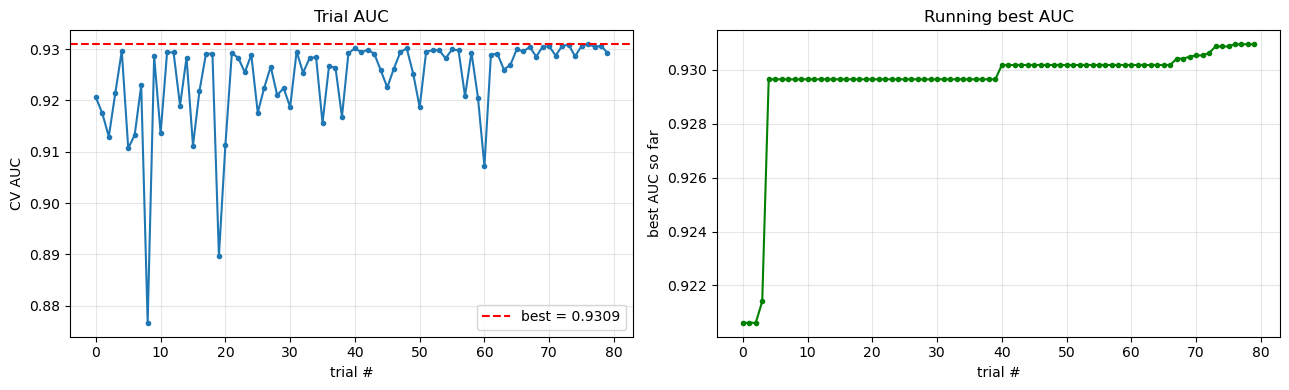

In [29]:
# Optuna study diagnostics — the value plot shows whether more trials would help.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vals = [t.value for t in study.trials if t.value is not None]
ax[0].plot(vals, marker=".")
ax[0].axhline(study.best_value, color="red", ls="--", label=f"best = {study.best_value:.4f}")
ax[0].set(title="Trial AUC", xlabel="trial #", ylabel="CV AUC")
ax[0].legend()
ax[0].grid(alpha=0.3)

running_best = np.maximum.accumulate(vals)
ax[1].plot(running_best, marker=".", color="green")
ax[1].set(title="Running best AUC", xlabel="trial #", ylabel="best AUC so far")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Train the final model on all of training data

Re-fit a fresh CatBoost with the Optuna-selected hyper-parameters on the entire training set, then inspect the in-sample report plus feature importances. (The honest performance estimate is the CV AUC reported above — this section is just a sanity check.)

In [30]:
best_model = CatBoostClassifier(
    **study.best_params,
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)
final_pipe = Pipeline([("prep", preprocessor), ("model", best_model)])
final_pipe.fit(X, y)

train_probs = final_pipe.predict_proba(X)[:, 1]
train_preds = (train_probs >= 0.5).astype(int)

print(f"Training AUC      : {roc_auc_score(y, train_probs):.4f}")
print(f"Training accuracy : {accuracy_score(y, train_preds):.4f}")
print(f"Training F1       : {f1_score(y, train_preds):.4f}")
print("\nConfusion matrix (train):")
print(confusion_matrix(y, train_preds))
print("\nClassification report (train):")
print(classification_report(y, train_preds, digits=4))

Training AUC      : 0.9645
Training accuracy : 0.9014
Training F1       : 0.9015

Confusion matrix (train):
[[3129  323]
 [ 363 3139]]

Classification report (train):
              precision    recall  f1-score   support

           0     0.8960    0.9064    0.9012      3452
           1     0.9067    0.8963    0.9015      3502

    accuracy                         0.9014      6954
   macro avg     0.9014    0.9014    0.9014      6954
weighted avg     0.9014    0.9014    0.9014      6954



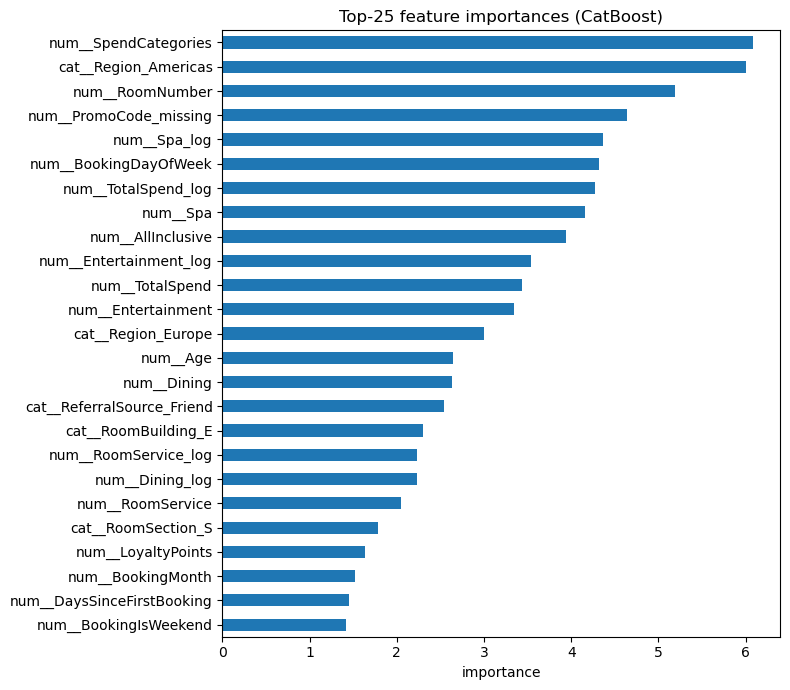

In [31]:
# Top-25 feature importances from the tuned CatBoost model (PredictionValuesChange).
feature_names = final_pipe.named_steps["prep"].get_feature_names_out()
importances = final_pipe.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
fi[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top-25 feature importances (CatBoost)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 8. Predict on the test set + write `submission.csv`

We threshold predicted probabilities at 0.5 to produce hard 0/1 labels as required, then write a two-column `GuestID,Churned` file next to the notebook.

In [32]:
test_probs = final_pipe.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    "GuestID": test_fe[ID_COL].values,
    "Churned": test_preds,
})
submission.to_csv("submission.csv", index=False)

print(f"Wrote submission.csv with {len(submission)} rows")
print(f"Predicted churn rate: {submission['Churned'].mean():.2%}")
submission.head()

Wrote submission.csv with 1739 rows
Predicted churn rate: 49.34%


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,1
4,635228,0


## 9. Notes for future iterations

* **Threshold tuning.** We hard-coded 0.5 because the deliverable wants {0,1}. If the grader uses F1 or business cost, sweep the threshold on out-of-fold predictions and pick the operating point that maximises that metric.
* **More trials.** TPE keeps improving with more samples. Doubling `N_TRIALS` usually squeezes another 1–2 AUC points out without changing the search space.
* **Native categorical handling.** CatBoost can take raw categorical columns directly via the `cat_features` argument. Bypassing the one-hot encoder for it (while keeping it for the linear baseline) may improve performance further.
* **More feature engineering.** Promising directions: interactions between `Region` and `PackageType`, ratios like `Spa / TotalSpend`, and treating `RoomNumber` modulo per-building floor counts.
* **Stacking.** Average the tuned CatBoost with a tuned `LogisticRegression` on the same preprocessor — these two often disagree on different rows, so a simple average tends to nudge AUC up.